In [ ]:
!pip install pandas matplotlib

import ast
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('stats-2023-01-01_2023-12-14.csv')
df['industries'] = df['industries'].apply(ast.literal_eval)

print(f'Number of samples: {df.shape[0]}')
print(f'And columns: {df.columns}')

Number of samples: 898935
And columns: Index(['Unnamed: 0', 'uuid', 'published', 'characters', 'sentences',
       'word_tok', 'sp_tok', 'cl100k_tok', 'country', 'language', 'media_type',
       'industries', 'rel_path', 'title'],
      dtype='object')


Compute text length distributions

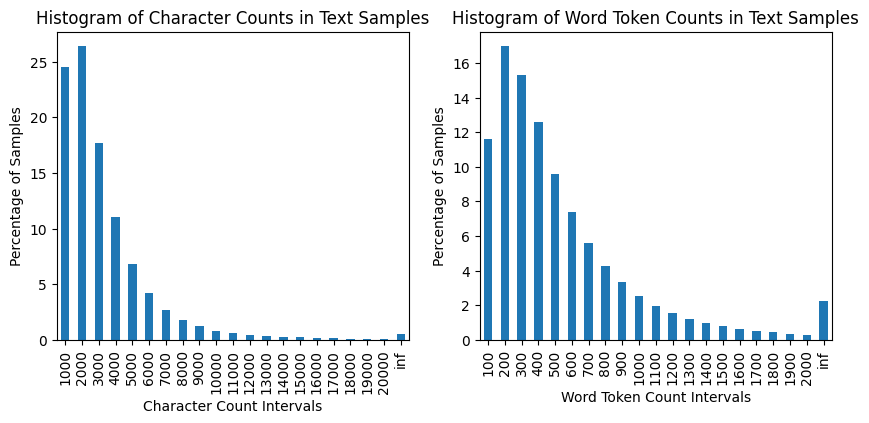

In [3]:
char_bins = [i for i in range(0, 20001, 1000)]
char_bins.append(float('inf'))
char_histogram_counts = pd.cut(df['characters'], bins=char_bins).value_counts().sort_index()
char_histogram_percentages = (char_histogram_counts / df.shape[0]) * 100

word_bins = [i for i in range(0, 2001, 100)]
word_bins.append(float('inf'))
word_histogram_counts = pd.cut(df['word_tok'], bins=word_bins).value_counts().sort_index()
word_histogram_percentages = (word_histogram_counts / df.shape[0]) * 100

sent_bins = [i for i in range(0, 2001, 100)]
sent_bins.append(float('inf'))
sent_histogram_counts = pd.cut(df['sentences'], bins=sent_bins).value_counts().sort_index()
sent_histogram_percentages = (sent_histogram_counts / df.shape[0]) * 100

fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns
char_histogram_percentages.plot(
    ax=axs[0], kind='bar',
    title='Histogram of Character Counts in Text Samples', 
    xlabel='Character Count Intervals',
    ylabel='Percentage of Samples'
)
axs[0].set_xticklabels(char_bins[1:])
word_histogram_percentages.plot(
    ax=axs[1], kind='bar', 
    title='Histogram of Word Token Counts in Text Samples', 
    xlabel='Word Token Count Intervals',
    ylabel='Percentage of Samples'
)
axs[1].set_xticklabels(word_bins[1:])
plt.show()

Compute distribution by language

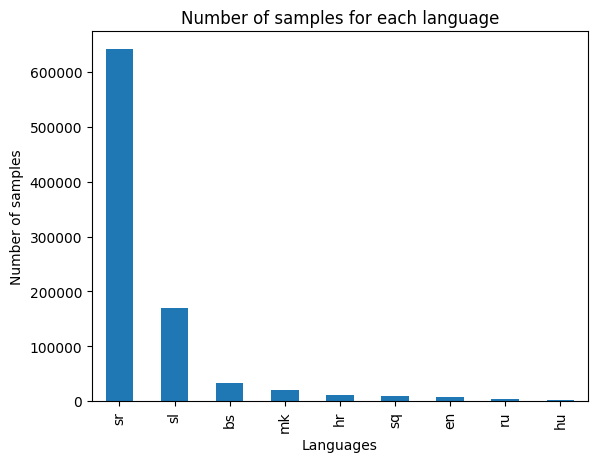

In [4]:
import matplotlib.pyplot as plt

language_counts = df['language'].value_counts()
filtered_language_counts = language_counts[language_counts > 100]
filtered_language_counts.plot(kind='bar')
plt.xlabel('Languages')
plt.ylabel('Number of samples')
plt.title('Number of samples for each language')
plt.show()

And distributions over Industries / Domains

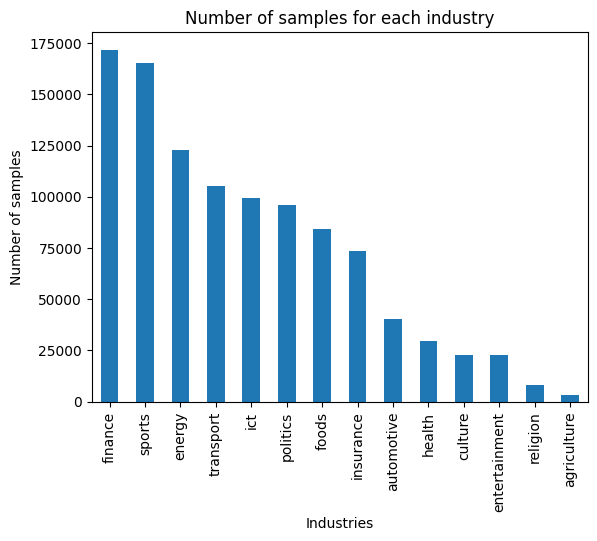

In [5]:
industries = df['industries'].explode()
industries.value_counts().plot(kind='bar')
plt.xlabel('Industries')
plt.ylabel('Number of samples')
plt.title('Number of samples for each industry')
plt.show()

Compute average characters, words and sentences per sub-word token for each language. (cl100k_base and SentencePiece encodings)

In [6]:
df['char_cl100k_ratio'] = df['characters'] / df['cl100k_tok']
df['word_cl100k_ratio'] = df['word_tok'] / df['cl100k_tok']
df['sent_cl100k_ratio'] = df['sentences'] / df['cl100k_tok']
df['char_sp_ratio'] = df['characters'] / df['sp_tok']
df['word_sp_ratio'] = df['word_tok'] / df['sp_tok']
df['sent_sp_ratio'] = df['sentences'] / df['sp_tok']

language_statistics = df.groupby('language').agg(
    avg_chrs_cl100k=pd.NamedAgg(column='char_cl100k_ratio', aggfunc='mean'),
    avg_words_cl100k=pd.NamedAgg(column='word_cl100k_ratio', aggfunc='mean'),
    avg_sents_cl100k=pd.NamedAgg(column='sent_cl100k_ratio', aggfunc='mean'),
    avg_chrs_sp=pd.NamedAgg(column='char_sp_ratio', aggfunc='mean'),
    avg_words_sp=pd.NamedAgg(column='word_sp_ratio', aggfunc='mean'),
    avg_sents_sp=pd.NamedAgg(column='sent_sp_ratio', aggfunc='mean'),
    count=pd.NamedAgg(column='characters', aggfunc='count')
)

filtered_language_statistics = language_statistics[language_statistics['count'] > 1000].sort_values(by=['count'], ascending=[False])
display(filtered_language_statistics)

,avg_chrs_cl100k,avg_words_cl100k,avg_sents_cl100k,avg_chrs_sp,avg_words_sp,avg_sents_sp,count
language,,,,,,,
sr,2.448959,0.434388,0.026184,3.565964,0.631542,0.034171,641604
sl,2.575493,0.456461,0.025282,3.707582,0.654911,0.035518,170304
bs,2.588868,0.450874,0.022018,3.783180,0.657267,0.031764,33810
mk,1.894235,0.323099,0.012628,4.025046,0.684847,0.026495,20164
hr,2.641232,0.449647,0.021582,3.853306,0.654513,0.030803,11560
sq,2.450028,0.463412,0.019460,3.684946,0.696223,0.028953,9498
en,3.165298,0.554676,0.078203,3.339900,0.577981,0.066247,6991
ru,2.585006,0.455258,0.024528,3.755084,0.660263,0.035388,3051
hu,2.313944,0.382106,0.020216,3.583875,0.584648,0.030635,1662
